In [2]:
# Zdefiniowanie struktury
struct Dual{T <:Number} <:Number
     v::T
    dv::T
end
# powyższa wersja jest lepsza niż ta poniżej:
#struct Dual <:Number
#     v::Number
#    dv::Number
#end

In [3]:
a = Dual{Float64}(1.0, 0.0)
b = Dual{Float64}(2.0, 0.0)
a + b

LoadError: + not defined for Dual{Float64}

In [4]:
# Przeciążenie podstawowych operatorów
import Base: +, -, *, /
-(x::Dual)          = Dual(-x.v,       -x.dv)
+(x::Dual, y::Dual) = Dual( x.v + y.v,  x.dv + y.dv)
-(x::Dual, y::Dual) = Dual( x.v - y.v,  x.dv - y.dv)
*(x::Dual, y::Dual) = Dual( x.v * y.v,  x.dv * y.v + x.v * y.dv)
/(x::Dual, y::Dual) = Dual( x.v / y.v, (x.dv * y.v - x.v * y.dv)/y.v^2)

# Przeciążenie podstawowych funkcji
import Base: abs, sin, cos, tan, exp,log, sqrt, isless
abs(x::Dual)  = Dual(abs(x.v),sign(x.v)*x.dv)
sin(x::Dual)  = Dual(sin(x.v), cos(x.v)*x.dv)
cos(x::Dual)  = Dual(cos(x.v),-sin(x.v)*x.dv)
tan(x::Dual)  = Dual(tan(x.v), one(x.v)*x.dv + tan(x.v)^2*x.dv)
exp(x::Dual)  = Dual(exp(x.v), exp(x.v)*x.dv)
log(x::Dual)  = Dual(log(x.v), x.dv/x.v)
sqrt(x::Dual) = Dual(sqrt(x.v),.5/sqrt(x.v) * x.dv)
isless(x::Dual, y::Dual) = x.v < y.v;

In [5]:
# Pomocne funkcje
import Base: show
show(io::IO, x::Dual) = print(io, "(", x.v, ") + [", x.dv, "ϵ]");
value(x::Dual) = x.v;
partials(x::Dual) = x.dv;

In [6]:
# Promocja typów i konwersja
import Base: convert, promote_rule

In [7]:
convert(::Type{Dual{T}}, x::Dual) where T = Dual(convert(T, x.v), convert(T, x.dv))
@show Dual{Float64}[Dual(1,2), Dual(3,0)];

Dual{Float64}[Dual(1, 2), Dual(3, 0)] = Dual{Float64}[(1.0) + [2.0ϵ], (3.0) + [0.0ϵ]]


In [8]:
convert(::Type{Dual{T}}, x::Number) where T = Dual(convert(T, x), zero(T))
@show Dual{Float64}[1, 2, 3];

Dual{Float64}[1, 2, 3] = Dual{Float64}[(1.0) + [0.0ϵ], (2.0) + [0.0ϵ], (3.0) + [0.0ϵ]]


In [9]:
promote_rule(::Type{Dual{T}}, ::Type{R}) where {T,R} = Dual{promote_type(T,R)}
@show Dual(1,2) * 3;

Dual(1, 2) * 3 = (3) + [6ϵ]


In [10]:
ReLU(x) = max(zero(x), x)
sigmoid(x) = one(x) / (one(x) + exp(-x))
tanh(x) = 2.0 / (one(x) + exp(-2.0x)) - one(x)
linear(x) = x
f(x) = x > zero(x) ? x : zero(x)
ε = Dual(0., 1.) # zarodek

(0.0) + [1.0ϵ]

In [11]:
x = -1.0:0.05:+1.0
y = sigmoid.(x .+ ϵ)

LoadError: UndefVarError: `ϵ` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

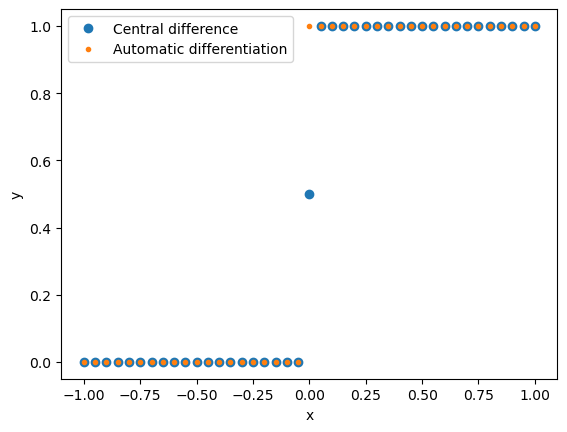

Python: <matplotlib.legend.Legend object at 0x7f615e159fd0>

In [12]:
center_diff(f, x_0; Δx=1e-3) = ( f(x_0 + 0.5Δx) - f(x_0 - 0.5Δx) ) / Δx
∇f = partials.(ReLU.(x .+ ε));
df = center_diff.(ReLU, x; Δx=1e-1)
using PythonPlot
plot(x, df, "o", label="Central difference")
plot(x, ∇f, ".", label="Automatic differentiation")
xlabel("x")
ylabel("y")
legend()

In [13]:
J = function jacobian(f, args::Vector{T}) where {T <:Number}
    jacobian_columns = Matrix{T}[]
    for i=1:length(args)
        x = Dual{T}[]
        for j=1:length(args)
            seed = (i == j)
            push!(x, seed ?
                Dual(args[j], one(args[j])) :
                Dual(args[j],zero(args[j])) )
        end
        column = partials.([f(x)...])
        push!(jacobian_columns, column[:,:])
    end
    hcat(jacobian_columns...)
end

jacobian (generic function with 1 method)

Dzięki temu możemy liczyć różniczki bardziej zaawansowanych funkcji, np. funkcję aktywacji SoftMax:

In [14]:
import LinearAlgebra: diagm
diagonal(m) = diagm(0 => vec(m))

softmax(x)  =  exp.(x) ./ sum(exp.(x));
dsoftmax(x) = (softmax(x) |> diagonal) .- softmax(x) * (softmax(x) |> transpose);

In [15]:
J(softmax, [0.1, 0.3, 0.99])

3×3 Matrix{Float64}:
  0.168634   -0.0563292  -0.112304
 -0.0563292   0.193498   -0.137169
 -0.112304   -0.137169    0.249473

In [16]:
dsoftmax([0.1, 0.3, 0.99])

3×3 Matrix{Float64}:
  0.168634   -0.0563292  -0.112304
 -0.0563292   0.193498   -0.137169
 -0.112304   -0.137169    0.249473

In [17]:
cross_entropy_loss(y, ŷ) = sum(-y .* log.(ŷ))
J(ŷ -> cross_entropy_loss([0.0, 1.0, 0.0], ŷ), [0.1, 0.3, 0.99])

1×3 Matrix{Float64}:
 -0.0  -3.33333  -0.0

In [18]:
dcross_entropy_loss(y, ŷ) = -y ./ ŷ
dcross_entropy_loss([0.0, 1.0, 0.0], [0.1, 0.3, 0.99])

3-element Vector{Float64}:
 -0.0
 -3.3333333333333335
 -0.0

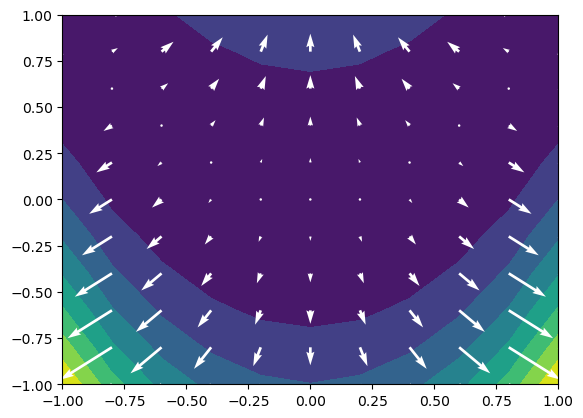

Python: <matplotlib.quiver.Quiver object at 0x7f615259b0e0>

In [20]:
rosenbrock(x, y) = (1.0 - x*x) + 100.0*(y - x*x)*(y - x*x)

v  = -1:.2:+1
n  = length(v)
xv = repeat(v, inner=n)
yv = repeat(v, outer=n)

z  = rosenbrock.(xv .+ ε, yv)
dx = 5e-4partials.(z)
z  = rosenbrock.(xv, yv .+ ε)
dy = 5e-4partials.(z)
zv = value.(z)

using PythonPlot
zv = reshape(zv, n, n)
contourf(v, v, zv)
quiver(xv[:], yv[:], dx, dy, color="white")

# No i jesteśmy w stanie nauczyć prostą sieć neuronową!

In [24]:
mean_squared_loss(y::Vector, ŷ::Vector) = sum(0.5(y - ŷ).^2)
fullyconnected(w::Vector, n::Number, m::Number, v::Vector, activation::Function) = activation.(reshape(w, n, m) * v)
Wh  = randn(10,2)
Wo  = randn(1,10)
dWh = similar(Wh)
dWo = similar(Wo)
x = [1.98;4.434]
y = [0.064]
E = Float64[]

function net(x, wh, wo, y)
    x̂ = fullyconnected(wh, 10, 2, x, sigmoid)
    ŷ = fullyconnected(wo, 1, 10, x̂, linear)
    E = mean_squared_loss(y, ŷ)
end

dnet_Wh(x, wh, wo, y) = J(w -> net(x, w, wo, y), wh);
dnet_Wo(x, wh, wo, y) = J(w -> net(x, wh, w, y), wo);

Ei     =  net(x, Wh[:], Wo[:], y)

0.9657481740764101

Poniżej zaimplementowana metoda najszybszego spadku: 
gradienty `dWh` i `dWo` wskazują gradienty, czyli kierunki
najszybszego **wzrostu** wartości funkcji błędu

In [25]:
for epoch in 1:10
    push!(E, Ei)
    dWh[:] = dnet_Wh(x, Wh[:], Wo[:], y);
    dWo[:] = dnet_Wo(x, Wh[:], Wo[:], y);
    Wh -= 0.1dWh
    Wo -= 0.1dWo
    
    Ei     =  net(x, Wh[:], Wo[:], y)
end

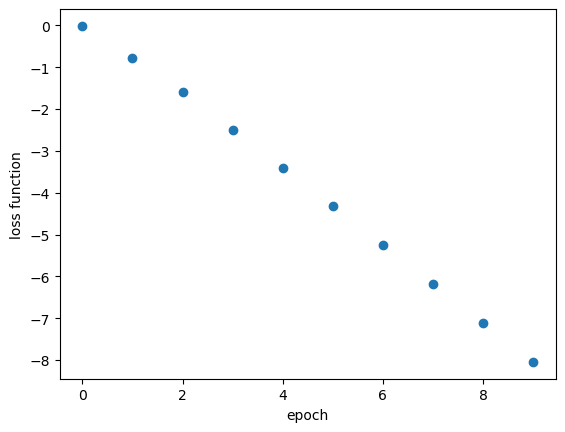

Python: Text(24.000000000000007, 0.5, 'loss function')

In [27]:
using PythonPlot
plot(log10.(E), "o", label="Loss function")
xlabel("epoch")
ylabel("loss function")